#Introducción

Esta es la segunda entrega del proyecto de inteligencia artificial 1, 2026-1, grupo C2.

Integrantes:
- Sergio Alejandro Ribero Ortiz - 2231885
- Nikolas Pedroso Mieles - 2231590
- Juan Gabriel García Jiménez - 2230083

### Dataset a utilizar

Para el proyecto, se decidió usar un dataset con 1000 entradas de peticiones de préstamos a un banco.
https://www.kaggle.com/datasets/amineipad/loan-approval-dataset

## Reto/Objetivo

Se desea desarrollar un estimador o predictor capaz de emular la toma de decisiones de la una entidad bancaria, específicamente respecto a su aprobación o rechazo de solicitudes de préstamos.

## Justificación IA

Debido a que no se conoce si depende de una fórmula o principio matemático, o si operadores humanos aceptan y rechazan cada caso bajo una evaluación individual, se considera que entrenar un modelo en base a resultados preexistentes asociados con la empresa es el mejor método disponible para crear una aproximación del criterio que se quiere estudiar.

##Características (features y target)

Se van a usar 6 características principales como features:

-Ingresos Anuales . . . . (Contínua)\
-Magnitud Crédito . . . .(Contínua)\
-Credit Score . . . . . . . . (Contínua)\
-No. Dependientes . . . .(Discreta: [0,4])\
-No. Créditos Vigentes (Discreta: [0,4])\
-Estado laboral . . . . . . .(Discreta: 3 estados)\
\
Por el otro lado, nuestra variable objetivo va a ser el estado de aprobación del crédito, pues al final del día es la aceptación o rechazo del crédito lo que termina importando para nuestros propósitos.

# Metodología

###Organización de datos

Debido a que se desconoce si se aplicó un método de sorteo en la creación del dataset, se decidió organizar los datos por etiqueta y revolverlos usando un sample sin reemplazo y con random_state.

De esta manera, se asegura reproducibilidad y se previene la alteración de la proporción entre clases que un sample con reemplazo podría causar.

###Método de partición
Como método de partición se usó KFold Estratificado de 10 particiones.
El uso de KFold viene dada por el volumen no tan grande de filas (1000) y la estratificación se utiliza para evitar sesgos debido al desbalance del dataset.

###Métrica a usar
Para otros contextos, puede que se priorice un estimador altamente sensible a una clase por sobre las demás.

Sin embargo, en este caso, se quiere aproximar la toma de decisiones de la entidad bancaria con la mayor fidelidad posible y, debido al desbalance del dataset, una métrica como la exactitud no sería de mucha utilidad, por lo que se va a priorizar f1-score por sobre las demás métricas.

In [40]:
#@title Librerías
import numpy as np              #Matemática y arreglos
import pandas as pd             #DataFrames y lectura del CSV
import matplotlib.pyplot as plt #Graficación
import seaborn as sns           #Graficación
from scipy import stats         #Distribuciones

#sklearn
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from matplotlib import gridspec
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.model_selection import KFold, cross_val_score, train_test_split

In [41]:
#@title Montar drive (sin usar)
'''
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
'''

"\nimport os\nfrom google.colab import drive\ndrive.mount('/content/drive', force_remount=True)\n"

In [42]:
#@title Cargar el dataset

df =  pd.read_csv("https://raw.githubusercontent.com/Khyii/ia1-los_banqueros-prediccion_aprobacion_de_prestamo/refs/heads/main/loan_approval.csv", sep=",").copy()

In [43]:
#@title Procesamiento de datos

#Cambiar estado laboral a representación numérica
df.employment_status = df.employment_status.factorize()[0]
df

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,0,1
1,2,49,Male,Married,112197,23556,789,0,2,1,1
2,3,35,Male,Divorced,84429,27052,372,1,4,0,0
3,4,63,Female,Single,124195,11313,808,3,4,2,1
4,5,28,Female,Married,81627,13315,689,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
995,996,53,Female,Married,135598,6014,767,3,2,1,1
996,997,22,Male,Single,139028,15103,662,0,0,2,1
997,998,34,Female,Married,147517,21986,582,0,2,1,1
998,999,60,Female,Divorced,73161,49781,635,4,0,0,1


# Modelo 1: Naive

loan_approved
Aprobado     0.729
Rechazado    0.271
Name: proportion, dtype: float64

Balance de clases — ratio: 72.90% aprobados


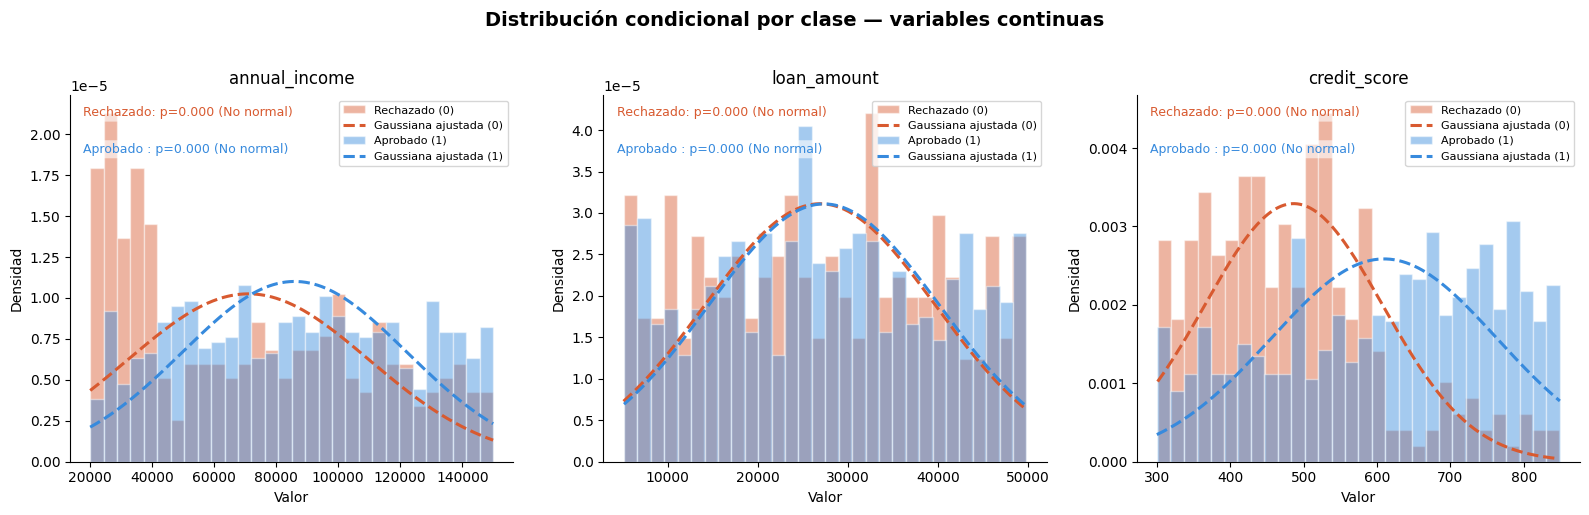

In [44]:
#@title Histogramas variables continuas

TARGET       = 'loan_approved'          # 1 = aprobado, 0 = rechazado
CONT_VARS    = ['annual_income', 'loan_amount', 'credit_score']
DISC_VARS    = ['num_dependents', 'existing_loans_count', 'employment_status']

# Verificación rápida
print(df[TARGET].value_counts(normalize=True).rename({1:'Aprobado', 0:'Rechazado'}))
print(f"\nBalance de clases — ratio: {df[TARGET].mean():.2%} aprobados")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución condicional por clase — variables continuas',
             fontsize=14, fontweight='bold', y=1.02)

colores = {1: '#378ADD', 0: '#D85A30'}   # azul = aprobado, coral = rechazado
etiquetas = {1: 'Aprobado (1)', 0: 'Rechazado (0)'}

for ax, var in zip(axes, CONT_VARS):
    for clase in [0, 1]:
        datos = df.loc[df[TARGET] == clase, var].dropna()

        # Histograma normalizado (densidad)
        ax.hist(datos, bins=30, density=True, alpha=0.45,
                color=colores[clase], label=etiquetas[clase], edgecolor='white')

        # Curva gaussiana ajustada — esto es lo que GNB asume
        mu, sigma = datos.mean(), datos.std()
        x = np.linspace(datos.min(), datos.max(), 300)
        ax.plot(x, stats.norm.pdf(x, mu, sigma),
                color=colores[clase], linewidth=2.2,
                linestyle='--', label=f'Gaussiana ajustada ({clase})')

        # Test de normalidad (Shapiro si n<5000, KS si no)
        if len(datos) < 5000:
            stat, p = stats.shapiro(datos.sample(min(len(datos), 5000), random_state=42))
            test_name = 'Shapiro'
        else:
            stat, p = stats.kstest(datos, 'norm', args=(mu, sigma))
            test_name = 'KS'

        ax.set_title(var, fontsize=12, pad=8)
        ax.set_xlabel('Valor')
        ax.set_ylabel('Densidad')

    # Texto con p-valores de normalidad por clase
    for i, clase in enumerate([0, 1]):
        datos = df.loc[df[TARGET] == clase, var].dropna()
        mu, sigma = datos.mean(), datos.std()
        if len(datos) < 5000:
            _, p = stats.shapiro(datos.sample(min(len(datos), 5000), random_state=42))
        else:
            _, p = stats.kstest(datos, 'norm', args=(mu, sigma))
        verdict = 'Normal' if p > 0.05 else 'No normal'
        color_txt = colores[clase]
        ax.annotate(f'{etiquetas[clase][:9]}: p={p:.3f} ({verdict})',
                    xy=(0.03, 0.97 - i*0.10), xycoords='axes fraction',
                    fontsize=9, color=color_txt, va='top',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

    ax.legend(fontsize=8, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('histogramas_continuas.png', dpi=150, bbox_inches='tight')
plt.show()

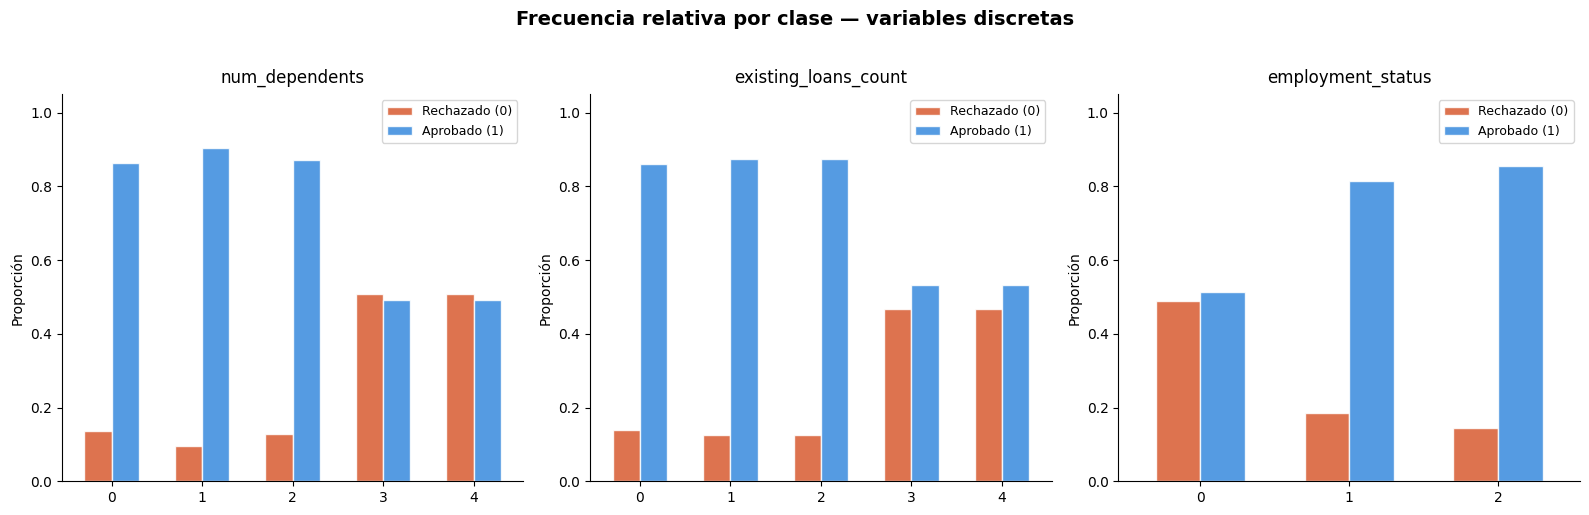

In [45]:
#@title Histogramas variables discretas

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle('Frecuencia relativa por clase — variables discretas',
             fontsize=14, fontweight='bold', y=1.02)

for ax, var in zip(axes, DISC_VARS):
    # Frecuencia relativa dentro de cada clase
    tabla = df.groupby([var, TARGET]).size().unstack(fill_value=0)
    tabla = tabla.div(tabla.sum(axis=1), axis=0)   # normalizar por fila

    tabla.plot(kind='bar', ax=ax, color=[colores[0], colores[1]],
               edgecolor='white', width=0.6, alpha=0.85)

    ax.set_title(var, fontsize=12, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Proporción')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['Rechazado (0)', 'Aprobado (1)'], fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('histogramas_discretas.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
#@title Ajuste de datos


# Columnas que NO usaremos
#import warnings
#warnings.filterwarnings('ignore')



# ── Las 6 variables seleccionadas ─────────────────────────────────
FEATURES = [
    'annual_income',        # Ingresos Anuales      — continua
    'loan_amount',          # Magnitud Crédito       — continua
    'credit_score',         # Credit Score           — continua
    'num_dependents',       # No. Dependientes       — discreta [0,4]
    'existing_loans_count', # No. Créditos Vigentes  — discreta [0,4]
    'employment_status',    # Estado Laboral         — categórica 3 estados
]
TARGET = 'loan_approved'

X = df[FEATURES]
y = df[TARGET]

print(f"\nShape de X : {X.shape}")
print(f"Variables  : {X.columns.tolist()}")

approvePrior = y.mean()
print(f"\nBalance — Aprobados : {approvePrior*100:.1f}%  |  Rechazados : {(1-approvePrior)*100:.1f}%")



Shape de X : (1000, 6)
Variables  : ['annual_income', 'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count', 'employment_status']

Balance — Aprobados : 72.9%  |  Rechazados : 27.1%


In [47]:
#@title Modelo y Stratified K-Fold
# Sin preprocesamiento — GNB directo sobre las 6 variables originales
gnb = GaussianNB()

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

cv_results = cross_validate(
    gnb,
    X,
    y,
    cv=kf,
    scoring='f1_weighted',
    return_train_score=True
)

print("=" * 50)
print("   RESULTADOS — K-Fold (k=10)")
print("=" * 50)
print(f"\n    val : {cv_results['test_score'].mean():.4f}  ±  {cv_results['test_score'].std():.4f}")
print(f"  train : {cv_results['train_score'].mean():.4f}  ±  {cv_results['train_score'].std():.4f}")

   RESULTADOS — K-Fold (k=10)

    val : 0.8104  ±  0.0342
  train : 0.8171  ±  0.0044


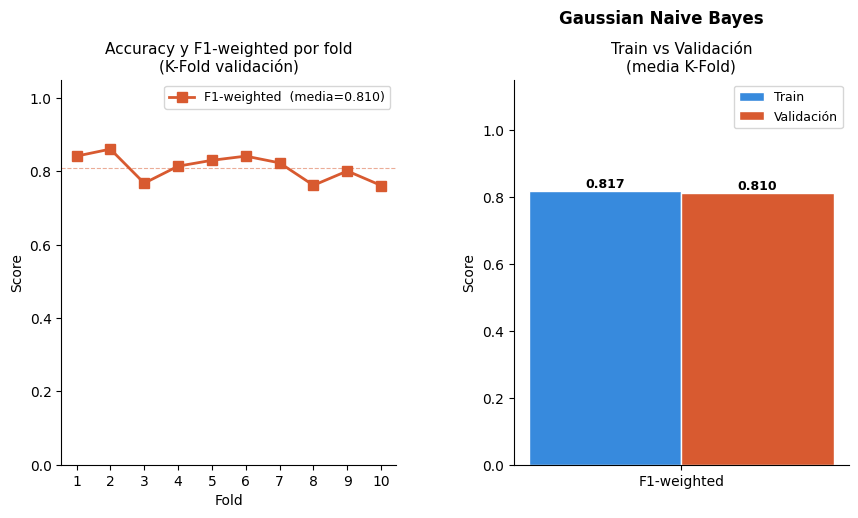

In [48]:
#@title Visualizacion
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── 1. Accuracy y F1-weighted por fold ──────────────────────────────
ax1 = fig.add_subplot(gs[0])
folds    = np.arange(1, 11)
#acc_vals = cv_results['test_score']
f1_vals  = cv_results['test_score']

#ax1.plot(folds, acc_vals, 'o-', color='#378ADD', linewidth=2,
#         markersize=7, label=f'Accuracy  (media={acc_vals.mean():.3f})')
ax1.plot(folds, f1_vals,  's-', color='#D85A30', linewidth=2,
         markersize=7, label=f'F1-weighted  (media={f1_vals.mean():.3f})')
#ax1.axhline(acc_vals.mean(), color='#378ADD', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.axhline(f1_vals.mean(),  color='#D85A30', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_xlabel('Fold')
ax1.set_ylabel('Score')
ax1.set_title('Accuracy y F1-weighted por fold\n(K-Fold validación)', fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.set_xticks(folds)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# ── 2. Barras comparativas train vs val ───────────────────────────
ax2 = fig.add_subplot(gs[1])
metricas  = [#'Accuracy',
             'F1-weighted']
train_med = [#cv_results['train_accuracy'].mean(),
             cv_results['train_score'].mean()]
val_med   = [#cv_results['test_accuracy'].mean(),
             cv_results['test_score'].mean()]

x     = np.arange(len(metricas))
width = 0.32
bars1 = ax2.bar(x - width/2, train_med, width, label='Train', color='#378ADD', edgecolor='white')
bars2 = ax2.bar(x + width/2, val_med,   width, label='Validación', color='#D85A30', edgecolor='white')

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(metricas)
ax2.set_ylabel('Score')
ax2.set_title('Train vs Validación\n(media K-Fold)', fontsize=11)
ax2.set_ylim(0, 1.15)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)



plt.suptitle('Gaussian Naive Bayes',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig('gnb_sin_transformar.png', dpi=150, bbox_inches='tight')
plt.show()

#Modelo 2: Decision Tree

In [49]:
#@title Toma de features y target
X_DT = df[["annual_income", "loan_amount", "credit_score", "num_dependents", "existing_loans_count", "employment_status"]]
y_DT = df["loan_approved"]

F1 Score values:
[0.79014925 0.86579044 0.8470983  0.84       0.8241411  0.83573333
 0.76489558 0.82830393 0.92638854 0.86538218]
Avg. F1 Score:
0.8387882667289093


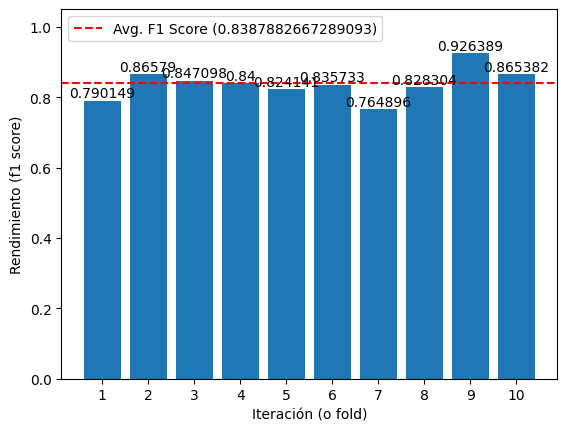

In [50]:
#@title Evaluación cross_val

dt = DecisionTreeClassifier(max_depth=3)

scoresDT = cross_val_score(dt, X_DT, y_DT, cv=kf, scoring="f1_weighted")

print("F1 Score values:")
print(scoresDT)

DT_mean = scoresDT.mean()
print("Avg. F1 Score:")
print(DT_mean)

iters = np.arange(1,11)
bars = plt.bar(iters,scoresDT)
plt.axhline(DT_mean, color="r", ls="--", label="Avg. F1 Score ("+ str(DT_mean) +")")

plt.xlabel("Iteración (o fold)")
plt.ylabel("Rendimiento (f1 score)")
plt.ylim(0, 1.05)
plt.xticks(iters)
plt.bar_label(bars, label_type="edge")

plt.legend()
plt.show()

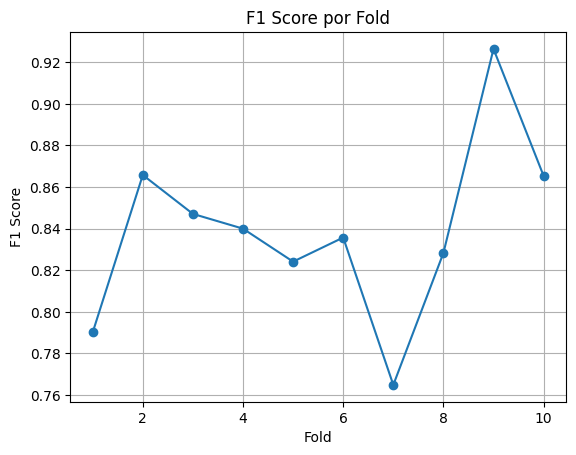

In [51]:
#@title Gráfica plot para el f1-score
plt.plot(range(1, 11), scoresDT, marker='o')

plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.title("F1 Score por Fold")
plt.grid(True)

plt.show()

# Modelo 3: Random Forest

In [52]:
#@title Toma de features y target

X_RF = df[["annual_income", "loan_amount", "credit_score", "num_dependents", "existing_loans_count", "employment_status"]]
y_RF = df["loan_approved"]

In [53]:
#@title Evaluación f1-score

#Crear y entrenar RF
rf = RandomForestClassifier(max_depth=3,n_estimators=50,random_state=21)
cv = cross_val_score(
    rf, X_RF, y_RF, cv=kf, scoring='f1_weighted'
)

print(f"F1 Score del modelo: {cv.mean()}")

F1 Score del modelo: 0.8927780245369208


#Modelo 4: Support Vector Machine

In [54]:
#@title Toma de features y target
X_SVM = df[["annual_income", "loan_amount", "credit_score", "num_dependents", "existing_loans_count", "employment_status"]]
y_SVM = df["loan_approved"]

In [55]:
#@title Evaluación cross_val

svc = SVC(C=5000, kernel='rbf')
scoresSVM = cross_val_score(svc, X_SVM, y_SVM, cv=kf, scoring="f1_weighted")

print(f"F1 Score para cada fold: {scoresSVM}")
print(f"F1 Score Promedio: {scoresSVM.mean()}")

F1 Score para cada fold: [0.69321429 0.72854713 0.6742699  0.63596081 0.65451453 0.61651786
 0.77375    0.67919206 0.72854713 0.67311127]
F1 Score Promedio: 0.6857624966418696


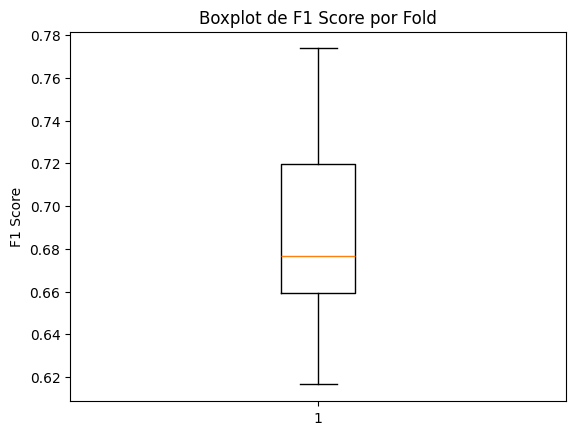

In [56]:
#@title Evaluación y boxplot

plt.boxplot(scoresSVM)
plt.ylabel("F1 Score")
plt.title("Boxplot de F1 Score por Fold")
plt.show()

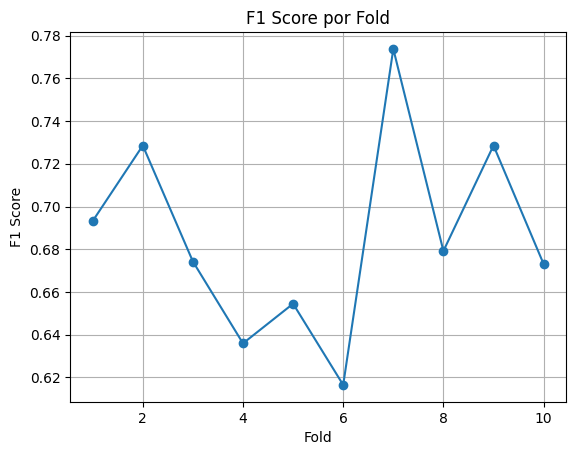

In [57]:
#@title Gráfica plot para f1-score
plt.plot(range(1, 11), scoresSVM, marker='o')

plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.title("F1 Score por Fold")
plt.grid(True)

plt.show()

# Conclusiones

- La capacidad del Gaussian NB para clasificar valores depende fuertemente de la distribución de los datos, y su utilidad sufre cuando evalua datos no distribuidos normalmente.

- El Decision Tree tuvo una puntuación sorprendentemente alta, dado el nivel de correlación entre variables y resultado. Esto puede indicar que el criterio de aprobación en la entidad bancaria está determinado por un conjunto rígido de reglas e intervalos.


- Como era de esperarse, aumentar y diversificar los Decision Trees involucrados en el proceso de aprobación mejoró la exactitud.

- A pesar de ser de los más complejos, el rendimiento del SVM fue menor a DT y RF, por lo que no se recomienda para pruebas futuras.